# Пошуковий аналіз даних

<h2>Мета</h2>

Ознайомитись з методами перевірки статистичних гіпотез. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати дані за допомогою візуалізацій
* Робити описовий аналіз
* Групувати дані для аналізу
* Знаходити зв'язок між ознаками
* Перевіряти гіпотези про значущість коефіцієнта кореляції та про вигляд закону розподілу
* Робити дисперсійний аналіз



<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачати дані із файлу, який зберегли наприкінці попередньої роботи (з виправленими помилками та заповненими пропусками). Записати дані у dataframe. Дослідити ознаки з метою виявлення звязку між ними, побудувавши їх візуалізації. Візуально оцініть наявність та силу зв'язку між ознаками.
2. Порахувати кореляцію між всіма кількісними ознаками
3. Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Які кількісні ознаки можуть бути предикторами кількості викидів СО2?
4. Побудувати діаграму розмаху для 'CO2 emission' по регіонам.
5. Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити ознаки з метою виявлення зв'язку між ними, побудувавши їх візуалізації</p>
</div>


Зчитую дані з файлу у датафрейм

In [38]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv ('/content/drive/MyDrive/adis/python2/Data2_clean.csv')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,9108.828,200.0,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0,164.427660


<div style="page-break-after: always;"></div>
Будую діаграми

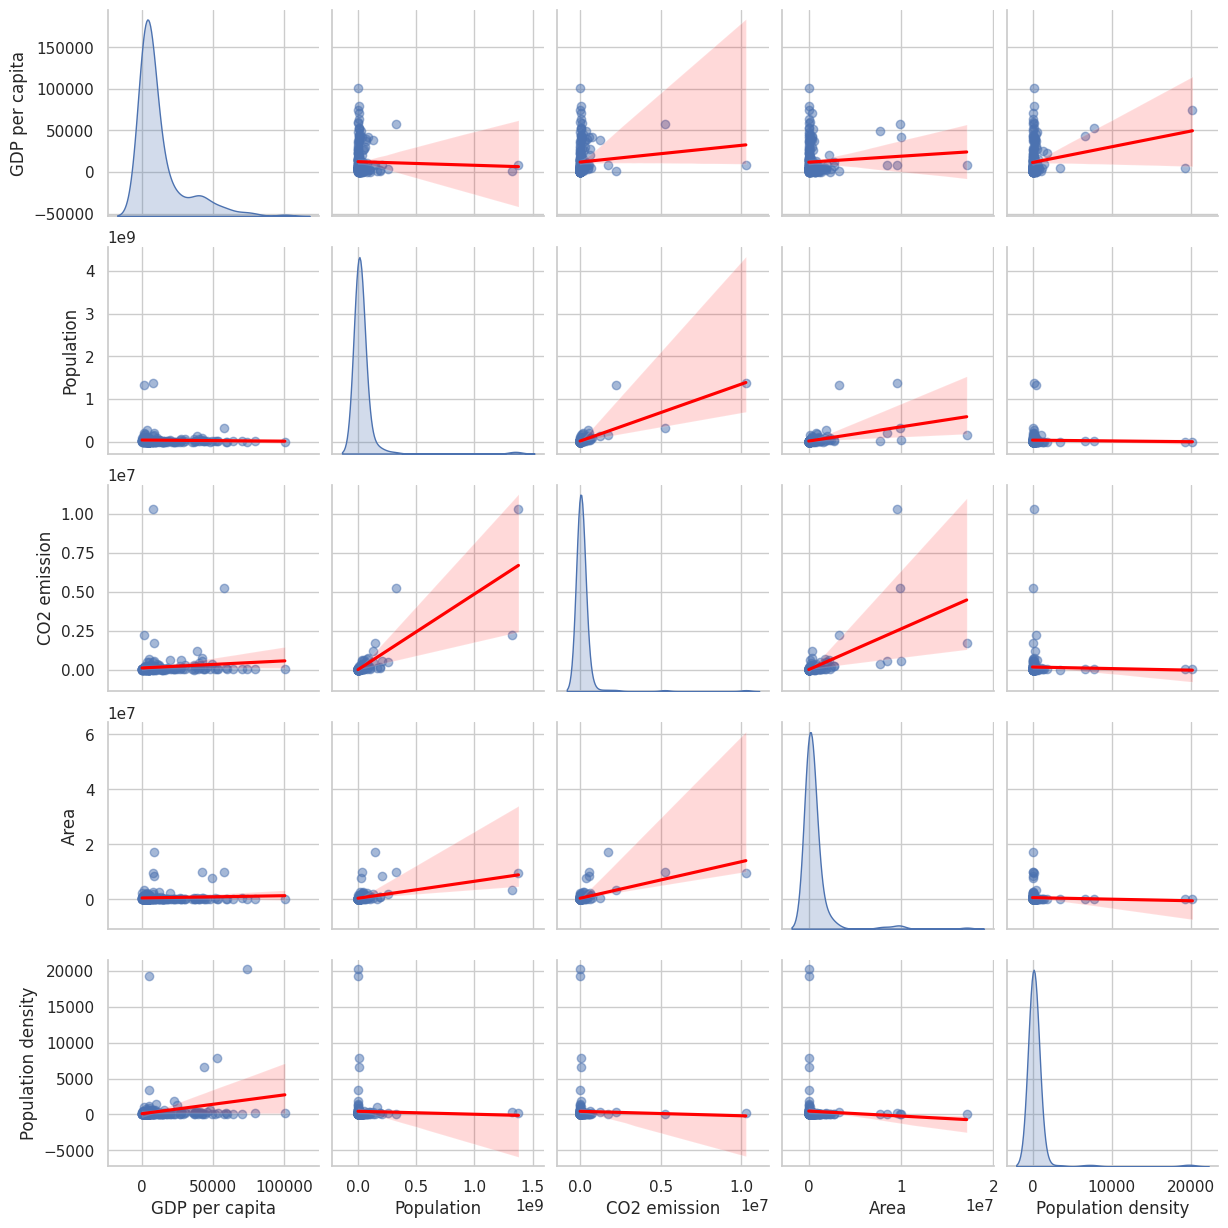

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.pairplot(
    numeric_df,
    kind='reg',
    diag_kind='kde',
    plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.5}}
)

plt.show()

1. **Аналіз розподілу (діагональ):** графіки щільності чітко демонструють, що всі досліджені кількісні ознаки мають яскраво виражену правосторонню асиметрію. Більшість значень зосереджена зліва (біля нуля), а праворуч тягнуться довгі «хвости». Це візуально підтверджує наявність країн-викидів з екстремально великими показниками економіки, населення чи площі.
2. **Аналіз взаємозв'язків (діаграми розсіювання):** найсильніший прямий лінійний зв'язок спостерігається між населенням (Population) та викидами CO2. Точки вишиковуються вздовж висхідної червоної лінії регресії, що вказує на те, що ці ознаки є хорошими предикторами одна для одної. <br>
У більшості інших пар (наприклад, ВВП та населення) спостерігається утворення щільних скупчень у лівому нижньому куті та розкид одиничних точок по осях. Червоні лінії регресії тут майже горизонтальні або дуже пологі. Це свідчить про слабкий лінійний зв'язок або його відсутність (наприклад, велике населення не гарантує високого ВВП на людину).

<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Порахувати кореляцію між всіма кількісними ознаками</p>
</div>


Рахую кореляцію між всіма кількісними ознаками

Таблиця коефіцієнтів кореляції:


,GDP per capita,Population,CO2 emission,Area,Population density
GDP per capita,1.000000,-0.034108,0.095141,0.076517,0.221827
Population,-0.034108,1.000000,0.804216,0.453695,-0.027515
CO2 emission,0.095141,0.804216,1.000000,0.588545,-0.024969
Area,0.076517,0.453695,0.588545,1.000000,-0.063047
Population density,0.221827,-0.027515,-0.024969,-0.063047,1.000000


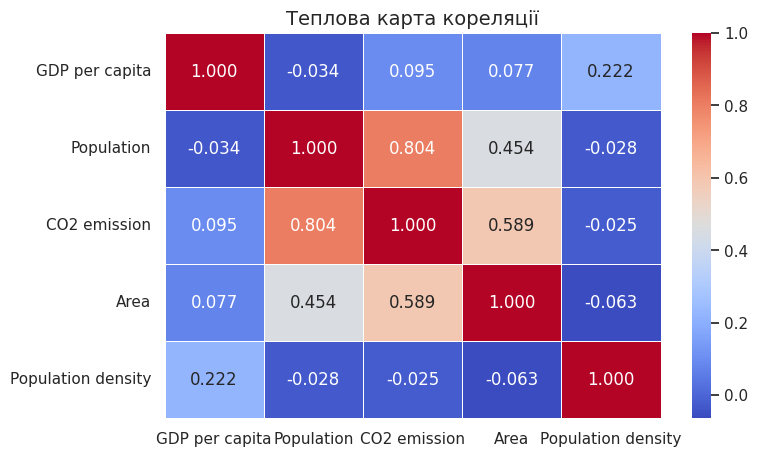

In [40]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr() #кореляція Пірсона

print("Таблиця коефіцієнтів кореляції:")
display(corr_matrix)

#теплова карта
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title("Теплова карта кореляції", fontsize=14)
plt.show()

Побудована теплова карта та матриця кореляції Пірсона дозволяють загалом оцінити силу лінійних зв'язків між усіма числовими ознаками датасету. За результатами розрахунків отримані пари ознак можна поділити на такі групи:
1. Сильний зв'язок (коефіцієнт ближче до 1): у цій категорії виділяється лише одна пара — населення (Population) та обсяг викидів (CO2 emission) із показником 0.80. Це найяскравіше виражена пряма залежність у даних.
2. Помірний зв'язок: до цієї групи належать дві пари. Це площа (Area) та викиди CO2 (0.59), а також площа та населення (0.45).
3. Слабкий зв'язок: спостерігається між рівнем ВВП на душу населення (GDP per capita) та щільністю населення (Population density) із показником 0.22.
4. Відсутність зв'язку (коефіцієнт близький до 0): усі інші можливі комбінації ознак (наприклад, вплив ВВП на викиди CO2 з показником 0.10 , або щільність населення та викиди з показником -0.02 ) не мають лінійної залежності, оскільки їхні показники наближені до нуля.

<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Візуально оцінити наявність та силу зв'язку між цими ознаками.</p>
</div>


Будую діаграму розсіювання для кількісних ознак та 'CO2 emission'

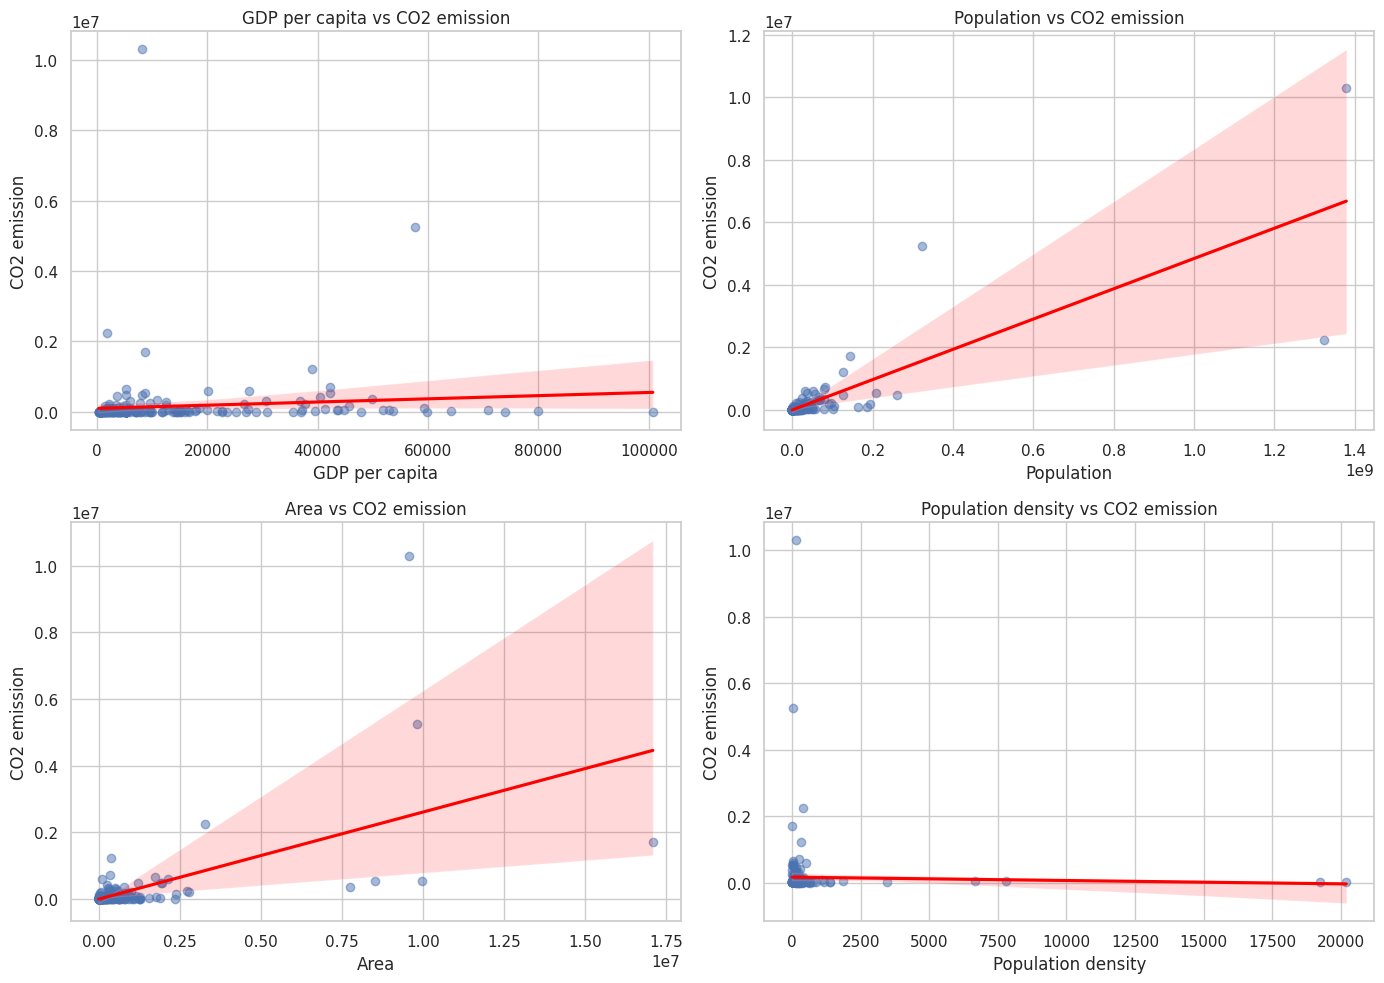

In [41]:
features = ['GDP per capita', 'Population', 'Area', 'Population density']

#сітка 2х2
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten() #робимо список осей плоским для зручності циклу

#будуємо графік для кожної ознаки в циклі
for i, feature in enumerate(features):
    sns.regplot(x=feature, y='CO2 emission', data=df, ax=axs[i],
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axs[i].set_title(f"{feature} vs CO2 emission", fontsize=12)

plt.tight_layout()
plt.show()

<p> <b> Які кількісні ознаки можуть бути предикторами кількості викидів СО2? </b></p>
<p>Населення (Population) є найкращим і найсильнішим предиктором. Червона лінія регресії має чіткий і стрімкий рух вгору, що свідчить про пряму лінійну залежність (чим більше людей живе в країні, тим більші обсяги викидів CO2). <br>
Площа (Area) також може бути хорошим предиктором. Лінія тренду помітно йде вгору, підтверджуючи пряму залежність, хоча точки розсіяні трохи сильніше, ніж на графіку з населенням.<br>
ВВП на душу населення (GDP per capita) та щільність населення (Population density) не є предикторами для загального обсягу викидів CO2. Червоні лінії на цих графіках майже абсолютно горизонтальні, що вказує на відсутність лінійного зв'язку.</p>

In [42]:
from scipy import stats

features = ['GDP per capita', 'Population', 'Area', 'Population density']

print("Аналіз предикторів для CO2 emission:\n")

for feature in features:
    #рахуємо Пірсона та p-value
    pearson_coef, p_value = stats.pearsonr(df[feature], df['CO2 emission'])

    print(f"{feature}")
    print(f"Коефіцієнт Пірсона: {pearson_coef:.4f}")

    if p_value < 0.001:
        print("P-value: < 0.001")
    else:
        print(f"P-value: {p_value:.4f}")
    print()

Аналіз предикторів для CO2 emission:

GDP per capita
Коефіцієнт Пірсона: 0.0951
P-value: 0.1625

Population
Коефіцієнт Пірсона: 0.8042
P-value: < 0.001

Area
Коефіцієнт Пірсона: 0.5885
P-value: < 0.001

Population density
Коефіцієнт Пірсона: -0.0250
P-value: 0.7145



Кількісні ознаки, які можуть бути предикторами кількості викидів СО2: населення (Population) та площа (Area). <br>
Population є найсильнішим предиктором. Коефіцієнт Пірсона становить 0.8042 (сильний прямий лінійний зв'язок), а P-value < 0.001 доводить, що цей зв'язок є статистично значущим і не є випадковістю.<br>
Area виступає помірним предиктором. Коефіцієнт Пірсона дорівнює 0.5885, а P-value також < 0.001, що підтверджує значущість зв'язку.<br>
Натомість ознаки ВВП на душу населення (GDP per capita) та щільність населення (Population density) не є предикторами. Їхній показник P-value значно перевищує стандартний рівень значущості (0.05). Це означає, що немає жодних статистичних доказів їхнього впливу на кількість викидів CO2.

<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудувати діаграму розмаху для 'CO2 emission' по регіонам. </p>
</div>


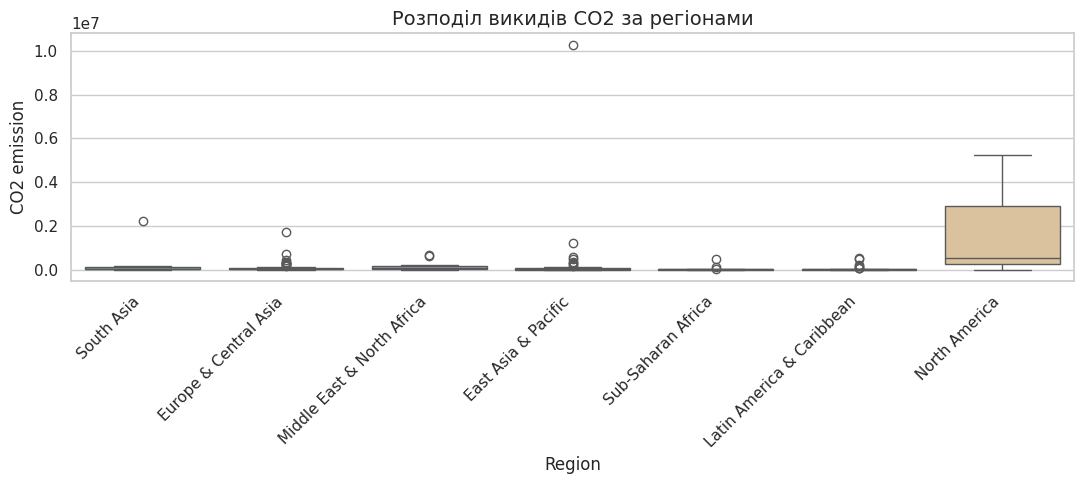

In [53]:
plt.figure(figsize=(11, 5))

sns.boxplot(x='Region', y='CO2 emission', data=df, hue='Region', palette='Set2', legend=False)

plt.xticks(rotation=45, ha='right') #повертаємо підписи на 45 градусів

plt.title("Розподіл викидів CO2 за регіонами", fontsize=14)

plt.tight_layout()
plt.show()

<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам</p>
</div>


Групую дані, щоб побачити чи впливає 'Region' на 'CO2 emission'.

In [44]:
df_group = df[['Region', 'CO2 emission']]
grouped_test = df_group.groupby('Region')

#виводимо перші кілька рядків з кожної групи, щоб перевірити, що все працює
grouped_test.head(2)

,Region,CO2 emission
0,South Asia,9809.225
1,Europe & Central Asia,5716.853
2,Middle East & North Africa,145400.217
3,East Asia & Pacific,9108.828
4,Europe & Central Asia,462.042
5,Sub-Saharan Africa,34763.160
6,Latin America & Caribbean,531.715
7,Latin America & Caribbean,204024.546
10,East Asia & Pacific,361261.839
14,Middle East & North Africa,31338.182


Перевіряю розподіл даних в групах, щоб обрати вид дисперсійного аналізу.

In [45]:
print("Перевірка на нормальність розподілу (тест Шапіро-Уїлка):\n")

for region in df['Region'].unique():
    #отримуємо дані для конкретного регіону (без порожніх значень, якщо вони є)
    region_data = grouped_test.get_group(region)['CO2 emission'].dropna()

    #виконуємо тест Шапіро-Уїлка
    stat, p_value = stats.shapiro(region_data)

    print(f"Регіон '{region}': p-value = {p_value:.5f}")

Перевірка на нормальність розподілу (тест Шапіро-Уїлка):

Регіон 'South Asia': p-value = 0.00000
Регіон 'Europe & Central Asia': p-value = 0.00000
Регіон 'Middle East & North Africa': p-value = 0.00001
Регіон 'East Asia & Pacific': p-value = 0.00000
Регіон 'Sub-Saharan Africa': p-value = 0.00000
Регіон 'Latin America & Caribbean': p-value = 0.00000
Регіон 'North America': p-value = 0.17752


Для отримання F-test score та P-value скористаюсь функцією <code>f_oneway</code> з модуля "stats" , якщо розподіл даних в групах дозволяє застосувати класичний дисперсійний аналіз, або <code>kruskal</code> з модуля "stats" для непараметричного дисперсійного аналізу Краскела-Уоліса.

In [46]:
#збираємо дані по всіх регіонах у список
regions_data = [grouped_test.get_group(region)['CO2 emission'].dropna() for region in df['Region'].unique()]

#виконуємо тест (розпаковуємо список через *)
result = stats.kruskal(*regions_data)

print(f"Результати тесту Краскела-Уоліса:")
print(f"H-statistic: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4e}")

Результати тесту Краскела-Уоліса:
H-statistic: 41.2187
P-value: 2.6222e-07


Результат із високим (41.22) показником тесту і P-value меншим за 0.05 показує, що існує статистично значуща різниця у кількості викидів CO2 залежно від географічного регіону. Але чи означає це, що досліджувані групи значуще відрізняються між собою?

Розглянемо їх окремо.

In [47]:
import itertools

regions = df['Region'].unique()

#створюємо всі можливі пари
for reg1, reg2 in itertools.combinations(regions, 2):
    data1 = grouped_test.get_group(reg1)['CO2 emission'].dropna()
    data2 = grouped_test.get_group(reg2)['CO2 emission'].dropna()

    stat, p_val = stats.mannwhitneyu(data1, data2)

    if p_val < 0.05:
        print(f"Є різниця: {reg1} vs {reg2} (p-value = {p_val:.4f})")

Є різниця: South Asia vs Sub-Saharan Africa (p-value = 0.0218)
Є різниця: Europe & Central Asia vs East Asia & Pacific (p-value = 0.0389)
Є різниця: Europe & Central Asia vs Sub-Saharan Africa (p-value = 0.0000)
Є різниця: Europe & Central Asia vs Latin America & Caribbean (p-value = 0.0008)
Є різниця: Middle East & North Africa vs East Asia & Pacific (p-value = 0.0101)
Є різниця: Middle East & North Africa vs Sub-Saharan Africa (p-value = 0.0000)
Є різниця: Middle East & North Africa vs Latin America & Caribbean (p-value = 0.0002)


Загальний тест Краскела-Уоліса підтвердив, що географічний регіон суттєво впливає на обсяги викидів CO2 у світі (p < 0.05). Однак детальне попарне порівняння за допомогою тесту Манна-Уїтні показало, що не всі регіони мають однакові рівні розбіжностей. Найбільш виражена статистична прірва з нульовим показником p спостерігається при порівнянні регіонів Europe & Central Asia та Middle East & North Africa з Sub-Saharan Africa.  Ці ж самі індустріально активні регіони — Європа та Близький Схід — також продемонстрували значущу різницю при зіставленні з Latin America & Caribbean (p = 0.0008 та 0.0002 відповідно) та East Asia & Pacific (p = 0.0389 та 0.0101). Крім того, незважаючи на візуальну схожість низьких показників на загальному графіку, тест виявив реальну статистичну відмінність між South Asia та Sub-Saharan Africa (p = 0.0218). Це доводить, що за межами загального результату дисперсійного аналізу ховається складна карта світу, де одні регіони вже сформували стійкі групи з високим рівнем викидів, тоді як інші суттєво відрізняються від них за техногенним впливом на довкілля.

<a name="task6"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>


1. По результатам дисперсійного аналізу для кількості викидів СО2 по регіонам, вкажіть пару регіонів, що відрізняються найсильніше.
2. Створіть якісну ознаку 'Rich country', згрупувавши дані 'GDP per capita' в кілька категорій (багаті-бідні країни, 3-5 категорій). Побудуйте діаграму розмаху для 'CO2 emission' по категоріям 'Rich country'. Візуально оцініть наявність зв'язку між цими ознаками.
3. Виконайте дисперсійний аналіз для 'CO2 emission', згрупувавши дані по категоріям 'Rich country'.

<details><summary>Натисніть тут, щоб побачити підказку</summary>

Групування кількісної змінної в категорії було в попередній лабораторній роботі. Використайте функцію "cut"
</details>

In [58]:
#1. пара регіонів, що відрізняються найбільше
print("1. Найбільша різниця між регіонами")
regions = df['Region'].dropna().unique()
min_p_value = 1.0
most_diff_pair = ()

#перебираємо циклом всі можливі пари регіонів
for r1, r2 in itertools.combinations(regions, 2):
    data1 = df[df['Region'] == r1]['CO2 emission'].dropna()
    data2 = df[df['Region'] == r2]['CO2 emission'].dropna()

    if len(data1) > 0 and len(data2) > 0:
        stat, p_val = stats.kruskal(data1, data2)
        #чим менший p-value, тим сильніша різниця
        if p_val < min_p_value:
            min_p_value = p_val
            most_diff_pair = (r1, r2)

print(f"Найбільше відрізняються: '{most_diff_pair[0]}' та '{most_diff_pair[1]}'")
print(f"Їхній p-value: {min_p_value:.4e}\n")

1. Найбільша різниця між регіонами
Найбільше відрізняються: 'Europe & Central Asia' та 'Sub-Saharan Africa'
Їхній p-value: 4.3093e-08



2. Візуалізація викидів за рівнем багатства


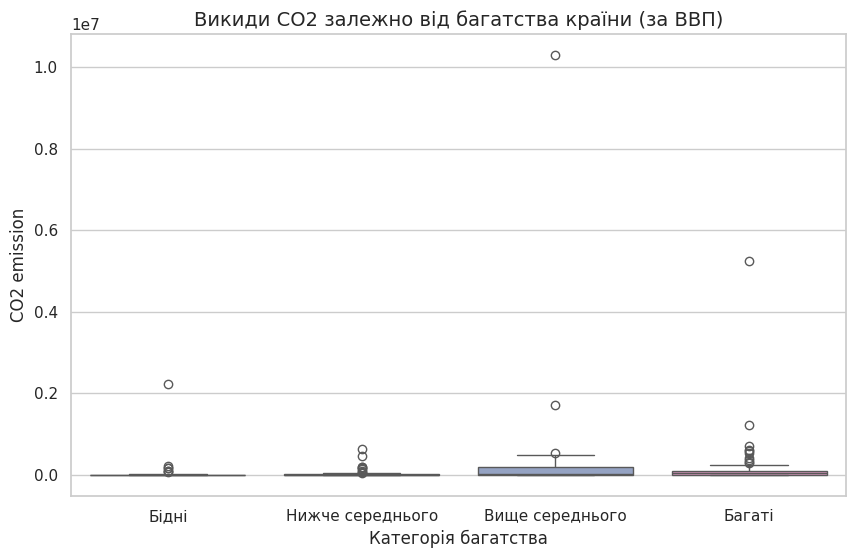

In [59]:
#2.Rich country та діаграма розмаху
print("2. Візуалізація викидів за рівнем багатства")
#qcut розіб'є всі країни на 4 рівні групи за їхнім ВВП
df['Rich country'] = pd.qcut(df['GDP per capita'], q=4, labels=['Бідні', 'Нижче середнього', 'Вище середнього', 'Багаті'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='Rich country', y='CO2 emission', data=df, hue='Rich country', palette='Set2', legend=False)
plt.title("Викиди CO2 залежно від багатства країни (за ВВП)", fontsize=14)
plt.ylabel("CO2 emission")
plt.xlabel("Категорія багатства")
plt.show()

In [60]:
#3.дисперсійний аналіз (Краскела-Уоліса) для Rich country
print("\n3. Дисперсійний аналіз для 'Rich country'")
grouped_rich = df.groupby('Rich country', observed=True)

#збираємо дані для кожної з 4 категорій багатства
categories_data = [grouped_rich.get_group(cat)['CO2 emission'].dropna() for cat in df['Rich country'].cat.categories]

#тест
result_rich = stats.kruskal(*categories_data)

print(f"H-statistic: {result_rich.statistic:.4f}")
print(f"P-value: {result_rich.pvalue:.4e}")

if result_rich.pvalue < 0.05:
     print("Висновок: Рівень багатства (ВВП) має статистично значущий вплив на обсяг викидів CO2.")
else:
     print("Висновок: Рівень багатства НЕ має впливу на викиди CO2.")


3. Дисперсійний аналіз для 'Rich country'
H-statistic: 30.1426
P-value: 1.2879e-06
Висновок: Рівень багатства (ВВП) має статистично значущий вплив на обсяг викидів CO2.


<h2>Виконала студентка групи ІП-44 <br> Бідюк Марія</h2>